# Chapter 2. The tree as metrics

**Week 1, Monday. Chapter 2 of 6: which branches make revenue, and can each be measured?**

**The need.** Meera asked what sales is made of. The answer is a tree: revenue is customers,
times orders per customer, times average order value, and order value is items per order times
price per item, less discounts. A branch helps her only when it is a metric, a numerator over a
denominator on one definition and one window.

| | |
|---|---|
| The metric at stake | Average order value (AOV), revenue over orders, the first branch this file can measure |
| Who asks | Meera, for the tree; marketing, whose payback case values each new customer by the order they place |
| What a wrong number costs | A tree built from two definitions multiplies to revenue nobody booked, and a budget is sized on it |
| A real company with the same question | Reliance reported Jio's quarter as its branches: 533 million subscribers and revenue per user of Rs 215.6 a month (Reliance Industries media release, 17 July 2026). A telecom's tree is customers times revenue per customer, stated the way this chapter states Kalpa's. |

Chapter 1 settled the readings of sales: Rs 5,44,810 booked on 30 orders, Rs 5,35,760 not
cancelled on 26, Rs 5,20,790 delivered on 21. This chapter builds the tree on top of them.

> **Kavya's review.** A branch you cannot divide is a label, not a metric. Give me each branch
> as a fraction, and tell me which ones this file cannot fill.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

for order in ORDERS:
    order["amount"] = int(order["amount"])     # chapter 1's fix, applied once
print(len(ORDERS), "orders loaded, every amount a whole number")

30 orders loaded, every amount a whole number


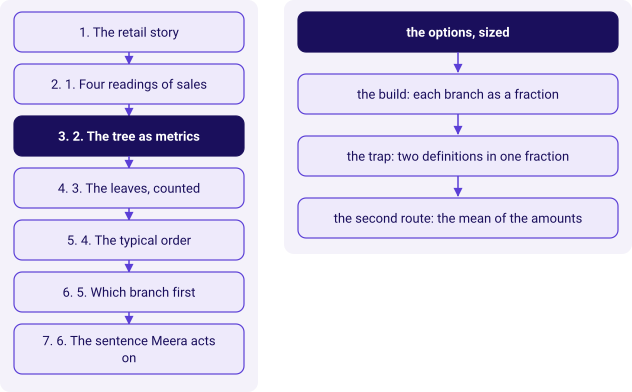

In [2]:
kit.side_by_side(
    kit.ladder(['The retail story', '1. Four readings of sales', '2. The tree as metrics', '3. The leaves, counted', '4. The typical order', '5. Which branch first', '6. The sentence Meera acts on'], lit=2, show=False),
    kit.vflow(['the options, sized', 'the build: each branch as a fraction', 'the trap: two definitions in one fraction', 'the second route: the mean of the amounts'], lit=0, show=False),
)

## The options

Which tree to draw depends on which fields the file holds.

| Option | Fields it needs | In this file? | What it can tell Meera |
|---|---|---|---|
| A. Revenue = orders x AOV | amount, one row per order | yes | the size of orders, and nothing about who buys |
| B. Revenue = customers x orders per customer x AOV | amount, customer id | yes | who buys, how often, and for how much |
| C. B, with AOV split into items x price, less discounts | items, list price, discount per order | no | which part of the basket moved |
| D. A funnel, visits to orders | sessions or footfall | no | where shoppers drop out before buying |

**The best-fit call.** B, since it is the deepest tree this file fills and it puts
marketing's branch, customers, beside the two it competes with. **What would change it:**
order lines with items and prices (the order-items table arrives later in the programme) move
the call to C; traffic data would add D in front.

In [3]:
fields = set(ORDERS[0])
needed = {"A": {"amount"}, "B": {"amount", "customer_id"},
          "C": {"amount", "customer_id", "items", "price", "discount"},
          "D": {"sessions", "amount"}}
kit.table(["option", "fields needed", "missing from this file"],
          [(k, ", ".join(sorted(v)), ", ".join(sorted(v - fields)) or "none") for k, v in needed.items()],
          caption="Each tree's fields against the file's " + str(len(fields)))
fillable = [k for k, v in needed.items() if v <= fields]
kit.check("options A and B are the ones this file can fill", fillable == ["A", "B"], fillable)

option,fields needed,missing from this file
A,amount,none
B,"amount, customer_id",none
C,"amount, customer_id, discount, items, price","discount, items, price"
D,"amount, sessions",sessions


## 1. The build: every branch as a fraction

**Predict before you run.** Booked revenue is split into orders times AOV. What does
multiplying the two back together give?

- a) Exactly booked revenue, because the average was made from that total.
- b) More than booked revenue, because repeat customers count twice.
- c) Less than booked revenue, because the average rounds down.
- d) Nothing useful until prices per item are known.

branch,numerator,denominator,in this file
customers,distinct customer ids,"none, it is a count",chapter 3 counts it
orders per customer,orders,distinct customers,chapter 3
average order value,revenue,orders,"Rs 18,160"
items per order,items sold,orders,not in this file
price per item,revenue before discounts,items sold,not in this file
discount rate,rupees discounted,revenue before discounts,not in this file


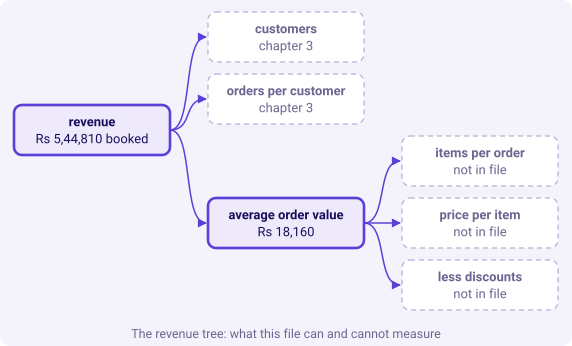

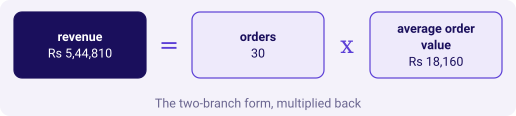

In [4]:
orders = len(ORDERS)
revenue = sum(order["amount"] for order in ORDERS)
aov = revenue / orders
kit.table(["branch", "numerator", "denominator", "in this file"],
          [("customers", "distinct customer ids", "none, it is a count", "chapter 3 counts it"),
           ("orders per customer", "orders", "distinct customers", "chapter 3"),
           ("average order value", "revenue", "orders", kit.rupees(aov)),
           ("items per order", "items sold", "orders", "not in this file"),
           ("price per item", "revenue before discounts", "items sold", "not in this file"),
           ("discount rate", "rupees discounted", "revenue before discounts", "not in this file")],
          caption="Every branch as a metric, booked definition, 1 July to 26 September")
kit.driver_tree({"label": "revenue", "note": kit.rupees(revenue) + " booked", "kind": "known", "children": [
    {"label": "customers", "note": "chapter 3", "kind": "unknown"},
    {"label": "orders per customer", "note": "chapter 3", "kind": "unknown"},
    {"label": "average order value", "note": kit.rupees(aov), "kind": "known", "children": [
        {"label": "items per order", "note": "not in file", "kind": "unknown"},
        {"label": "price per item", "note": "not in file", "kind": "unknown"},
        {"label": "less discounts", "note": "not in file", "kind": "unknown"}]}]},
    title="The revenue tree: what this file can and cannot measure")
kit.equation(["revenue\n" + kit.rupees(orders * aov), "=", f"orders\n{orders}", "x",
              "average order value\n" + kit.rupees(aov)], title="The two-branch form, multiplied back")

In [5]:
kit.check("orders x AOV lands on booked revenue", round(orders * aov) == revenue, kit.rupees(orders * aov))
kit.check("booked AOV is Rs 18,160", round(aov) == 18160, kit.rupees(aov))
missing = [b for b in ("items", "price", "discount") if b not in ORDERS[0]]
kit.check("three branches of six are not in this file", len(missing) == 3, missing)

**What happened.** The answer is a. That is the tree's strength and its limit: the product
always lands on revenue, so a wrong leaf never shows in the total and only shows in the split.
Whether Rs 18,160 describes an order anyone would recognise is chapter 4's question.

## 2. The trap: a fraction built from two definitions

Finance's report carries booked revenue. The operations dashboard counts delivered orders,
because delivery is what it runs. An analyst in a hurry takes one number from each.

**Predict before you run.** Booked rupees over delivered orders gives what AOV?

- a) Rs 18,160, the same as before.
- b) Rs 24,800, the delivered AOV.
- c) Rs 25,943.
- d) Rs 23,687.

**The plausible wrong answer.**

In [6]:
delivered_orders = sum(1 for order in ORDERS if order["status"] == "delivered")
delivered_revenue = sum(order["amount"] for order in ORDERS if order["status"] == "delivered")
hurried_aov = revenue / delivered_orders
print("AOV:", kit.rupees(hurried_aov), "(booked revenue / delivered orders)")
print("The tree then multiplies to:", kit.rupees(orders * hurried_aov), "on", orders, "orders")

AOV: Rs 25,943 (booked revenue / delivered orders)
The tree then multiplies to: Rs 7,78,300 on 30 orders


**Why it is wrong.** The answer is c. The numerator counts the 9 cancelled and returned orders'
rupees while the denominator has dropped those orders, so every order looks Rs 7,783 larger
than any booked order averages. Multiplied back through the tree it claims Rs 7,78,300 of
revenue, 43 percent more than anyone booked, and marketing's payback case would value a new
customer's order on it. The check is the tree's own identity: on one definition, orders times
AOV must land on that definition's revenue.

numerator / denominator,AOV,orders x AOV,lands on a real total?
booked / booked,"Rs 18,160","Rs 5,44,810",yes
delivered / delivered,"Rs 24,799","Rs 5,20,790",yes
"booked / delivered, the trap","Rs 25,943","Rs 5,44,810",no


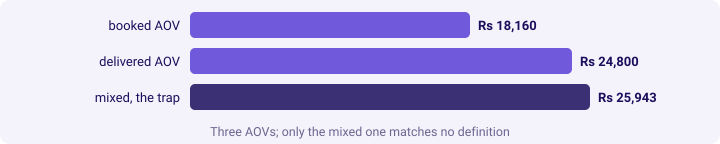

In [7]:
rows = [("booked / booked", revenue, orders), ("delivered / delivered", delivered_revenue, delivered_orders),
        ("booked / delivered, the trap", revenue, delivered_orders)]
kit.table(["numerator / denominator", "AOV", "orders x AOV", "lands on a real total?"],
          [(n, kit.rupees(r / o), kit.rupees(o * (r / o)),
            "yes" if (r, o) in [(revenue, orders), (delivered_revenue, delivered_orders)] else "no")
           for n, r, o in rows], caption="The identity check on each fraction")
kit.bars([("booked AOV", round(aov)), ("delivered AOV", round(delivered_revenue / delivered_orders)),
          ("mixed, the trap", round(hurried_aov))], fmt=kit.rupees, lit=(2,),
         title="Three AOVs; only the mixed one matches no definition")
kit.check("the mixed AOV is Rs 25,943", round(hurried_aov) == 25943)
kit.check("multiplied back on 30 orders, the mix claims revenue nobody booked",
          round(orders * hurried_aov) != revenue, kit.rupees(orders * hurried_aov))

**The fix, and what changed.** One definition per fraction: booked AOV is Rs 18,160 on 30
orders; delivered AOV is Rs 24,800 on 21 orders. The mixed Rs 25,943 goes nowhere. Each
number goes out with its definition, and the tree multiplies back on each.

> **Kavya's review.** When two reports feed one fraction, ask each report what it counts before
> you divide. The identity check costs one line and would have caught this before Meera saw it.

## A second route: AOV as the mean of the amounts

Revenue over orders is the mean of the 30 amounts, so a list and a mean must give the same
number. The two routes agree on every definition, and they are the same number: the mean is
what the tree calls AOV.

In [8]:
amounts = [order["amount"] for order in ORDERS]
mean_route = sum(amounts) / len(amounts)
import statistics
library_route = statistics.fmean(amounts)
kit.table(["route", "booked AOV"],
          [("revenue / orders", kit.rupees(aov)), ("sum of the list / its length", kit.rupees(mean_route)),
           ("statistics.fmean(amounts)", kit.rupees(library_route))],
          caption="Three routes to one AOV")
kit.check("revenue / orders equals the mean of the amounts", abs(aov - mean_route) < 1e-9)
kit.check("the library's mean agrees", abs(aov - library_route) < 1e-9)

route,booked AOV
revenue / orders,"Rs 18,160"
sum of the list / its length,"Rs 18,160"
statistics.fmean(amounts),"Rs 18,160"


**When to switch.** Revenue over orders is the route when the totals already exist in a
report; the mean of the list is the route when you hold the rows. `statistics.fmean` saves a
line and nothing else. The bigger switch is the one chapter 4 makes: when the question is
"what is a typical order", the mean may be the wrong middle altogether.

### In the interview

**[S] How would you increase sales for an online retailer?** "I would draw the revenue tree
before suggesting anything: customers, times orders per customer, times average order value,
with order value split into items, price and discounts. Then I measure each branch on the same
window and definition and ask which is short against plan, because each costs something
different to move: acquisition costs marketing, frequency costs retention, basket costs
merchandising, price risks volume. Initiatives come last, each placed on the branch it moves."

**[F] A business says "grow revenue 15 percent"; how do you turn that into questions data can
answer?** "Fifteen percent of which revenue, over which window, against which base. Then I break
the target down the tree and ask what each branch would have to do alone, in customers, orders
and rupees per order. Each is a fraction I can compute and each maps to a team that owns it."

### Depth: why the denominators cancel

Customers x (orders / customers) x (revenue / orders) = revenue, because each denominator
cancels the next numerator. That is also why a branch measured on another definition breaks
the chain: its denominator no longer matches its neighbour's numerator.

## What this chapter established

What we now know,The evidence
Each branch is a numerator over a denominator on one definition,"AOV = Rs 5,44,810 / 30 = Rs 18,160"
Three branches are not in this file,"items, price and discounts"
A fraction from two definitions matches nothing,"Rs 25,943 would claim Rs 7,78,300"


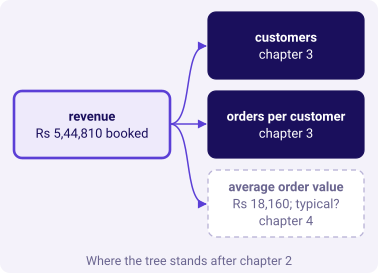

Next: chapter 3 counts the two customer branches from the rows.


In [9]:
kit.table(["What we now know", "The evidence"],
          [("Each branch is a numerator over a denominator on one definition", "AOV = Rs 5,44,810 / 30 = Rs 18,160"),
           ("Three branches are not in this file", "items, price and discounts"),
           ("A fraction from two definitions matches nothing", "Rs 25,943 would claim Rs 7,78,300")],
          caption="Chapter 2: the tree as metrics")
kit.driver_tree({"label": "revenue", "note": "Rs 5,44,810 booked", "kind": "known", "children": [
    {"label": "customers", "note": "chapter 3", "kind": "lit"},
    {"label": "orders per customer", "note": "chapter 3", "kind": "lit"},
    {"label": "average order value", "note": "Rs 18,160; typical? chapter 4", "kind": "unknown"}]},
    title="Where the tree stands after chapter 2")
kit.check_summary()
print("Next: chapter 3 counts the two customer branches from the rows.")